In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_clean.csv')

In [3]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1,1.0,0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3,1,43.0,0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2,1,20.0,0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,1,15.0,0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0


In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [5]:
#Defining input and Target Features

X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

In [6]:
#Seperating Numerical and Categorical Variables

num_features = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
cat_features = ["male", "education", "currentSmoker", "BPMeds", "prevalentStroke",
                "prevalentHyp", "diabetes"]

In [7]:
#Standard scaling numeric variables and applying oneHotEncoding to categorical variables

num_transformer = SkPipeline(steps=[
    ("scaler", StandardScaler())
])

cat_transformer = SkPipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

In [9]:
#Initial Results for Elastic net Regression without any tuning

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.35874439 0.36514523 0.33050847 0.3776824  0.3539823  0.36595745
 0.40758294 0.39069767 0.37037037 0.40930233]
Mean F1: 0.3729973557296812


In [10]:

#Initial Results for Elastic net Regression without any tuning

recall_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="recall")
precision_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="precision")
roc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

print("Mean Recall:", recall_scores.mean())
print("Mean Precision:", precision_scores.mean())
print("Mean ROC-AUC:", roc_scores.mean())

Mean Recall: 0.6584615384615384
Mean Precision: 0.2605955419204057
Mean ROC-AUC: 0.7187435579378258


In [11]:
#Initial Results for Elastic net Regression without any tuning

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
print("Mean Accuracy:", accuracy_scores.mean())

Mean Accuracy: 0.6625797314777644


In [12]:
#Applying Grid search to find the best l1_ratio

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.001 ],
    "model__l1_ratio": [0.1,  0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'model__C': 0.001, 'model__l1_ratio': 0.1}
Best score: 0.38077375401487124


In [13]:
best_model = grid.best_estimator_

print(best_model)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cigsPerDay',
                                                   'totChol', 'sysBP', 'diaBP',
                                                   'BMI', 'heartRate',
                                                   'glucose']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['male', 'education',
                                                   'currentSmoker', 'BPMeds',
                                                   'prevalentStrok

In [14]:
#Updated scores with l1_Ratio = 0.1

accuracy_scores = cross_val_score(best_model, X, y, cv=cv, scoring="accuracy")
precision_scores = cross_val_score(best_model, X, y, cv=cv, scoring="precision")
recall_scores = cross_val_score(best_model, X, y, cv=cv, scoring="recall")
f1_scores = cross_val_score(best_model, X, y, cv=cv, scoring="f1")
roc_auc_scores = cross_val_score(best_model, X, y, cv=cv, scoring="roc_auc")

print("Mean Accuracy:", accuracy_scores.mean())
print("Mean Precision:", precision_scores.mean())
print("Mean Recall:", recall_scores.mean())
print("Mean F1:", f1_scores.mean())
print("Mean ROC-AUC:", roc_auc_scores.mean())

Mean Accuracy: 0.6691946563183013
Mean Precision: 0.2666126550592889
Mean Recall: 0.6678846153846154
Mean F1: 0.38077375401487124
Mean ROC-AUC: 0.7225304265841132


In [15]:
#Applying decision threshold to improve recall  [best threshold = 0.4]

import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

best_model = grid.best_estimator_

# Out-of-fold predicted probabilities for class 1
y_prob = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold = {t:.2f}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print("Confusion Matrix:")
    print(cm)


Threshold = 0.10
Accuracy  : 0.1520
Precision : 0.1520
Recall    : 1.0000
F1 Score  : 0.2638
TN=0, FP=3594, FN=0, TP=644
Confusion Matrix:
[[   0 3594]
 [   0  644]]

Threshold = 0.20
Accuracy  : 0.1520
Precision : 0.1520
Recall    : 1.0000
F1 Score  : 0.2638
TN=0, FP=3594, FN=0, TP=644
Confusion Matrix:
[[   0 3594]
 [   0  644]]

Threshold = 0.30
Accuracy  : 0.2199
Precision : 0.1613
Recall    : 0.9845
F1 Score  : 0.2772
TN=298, FP=3296, FN=10, TP=634
Confusion Matrix:
[[ 298 3296]
 [  10  634]]

Threshold = 0.40
Accuracy  : 0.4512
Precision : 0.2016
Recall    : 0.8820
F1 Score  : 0.3281
TN=1344, FP=2250, FN=76, TP=568
Confusion Matrix:
[[1344 2250]
 [  76  568]]

Threshold = 0.50
Accuracy  : 0.6692
Precision : 0.2658
Recall    : 0.6677
F1 Score  : 0.3802
TN=2406, FP=1188, FN=214, TP=430
Confusion Matrix:
[[2406 1188]
 [ 214  430]]

Threshold = 0.60
Accuracy  : 0.7987
Precision : 0.3385
Recall    : 0.3401
F1 Score  : 0.3393
TN=3166, FP=428, FN=425, TP=219
Confusion Matrix:
[[3166  4

In [16]:
#Printing Cross Validated recall, precision, and accuracy with a decision threshold of 0.4

threshold = 0.40

recall_scores = []
precision_scores = []
accuracy_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    # Split data for this fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train best model on this fold
    model = grid.best_estimator_
    model.fit(X_train, y_train)

    # Get predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply custom threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate metrics
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    recall_scores.append(recall)
    precision_scores.append(precision)
    accuracy_scores.append(accuracy)

    print(f"Fold {fold}:")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print()

Fold 1:
  Recall:    0.8594
  Precision: 0.1971
  Accuracy:  0.4505

Fold 2:
  Recall:    0.9062
  Precision: 0.2079
  Accuracy:  0.4646

Fold 3:
  Recall:    0.8594
  Precision: 0.1937
  Accuracy:  0.4387

Fold 4:
  Recall:    0.9375
  Precision: 0.2128
  Accuracy:  0.4670

Fold 5:
  Recall:    0.8923
  Precision: 0.2101
  Accuracy:  0.4693

Fold 6:
  Recall:    0.8615
  Precision: 0.1944
  Accuracy:  0.4316

Fold 7:
  Recall:    0.8000
  Precision: 0.1926
  Accuracy:  0.4552

Fold 8:
  Recall:    0.8923
  Precision: 0.2101
  Accuracy:  0.4693

Fold 9:
  Recall:    0.9375
  Precision: 0.1993
  Accuracy:  0.4208

Fold 10:
  Recall:    0.8750
  Precision: 0.1979
  Accuracy:  0.4444



In [17]:
#Print cross-validated F1-Score and variance with a threshold of 0.4

threshold = 0.40

f1_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train best Elastic Net model
    model = grid.best_estimator_
    model.fit(X_train, y_train)

    # Get predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply threshold = 0.40
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

print("Cross-Validated F1 Scores for Elastic Net Regression")
print("Threshold = 0.40")
print("-----------------------------------------------")

for i, score in enumerate(f1_scores, start=1):
    print(f"Fold {i}: F1 Score = {score:.4f}")

print("-----------------------------------------------")
print(f"Mean F1 Score: {np.mean(f1_scores):.4f}")
print(f"Variance: {np.var(f1_scores):.6f}")
print(f"Standard Deviation: {np.std(f1_scores):.4f}")

Cross-Validated F1 Scores for Elastic Net Regression
Threshold = 0.40
-----------------------------------------------
Fold 1: F1 Score = 0.3207
Fold 2: F1 Score = 0.3382
Fold 3: F1 Score = 0.3161
Fold 4: F1 Score = 0.3468
Fold 5: F1 Score = 0.3402
Fold 6: F1 Score = 0.3173
Fold 7: F1 Score = 0.3104
Fold 8: F1 Score = 0.3402
Fold 9: F1 Score = 0.3288
Fold 10: F1 Score = 0.3228
-----------------------------------------------
Mean F1 Score: 0.3281
Variance: 0.000140
Standard Deviation: 0.0118


AUC: 0.7221438767856709


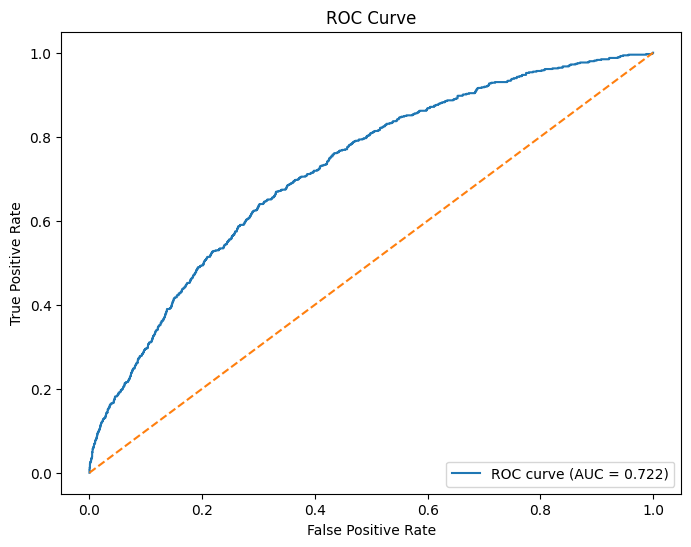

In [ ]:

#Plot the ROC-AUC curve for the Elastic net regression model

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

best_model = grid.best_estimator_

# probability for class 1 from cross-validated predictions
y_prob = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()